## Q2 Findings: Global Sales Over Time (1980-2015)

**Aggregate Industry Trajectory:**
- 1980-1995: pre-modern era, sales generally under $100M/year
- 1996: industry takeoff (single-year jump from $88M to $199M, +126%)
  - Coincides with PlayStation and Nintendo 64 mainstream launch window
- 2001-2008: sustained growth from ~$330M to peak of $678M
- 2008: dataset peak at $678M
- 2011-2015: significant decline from $515M to $264M (49% drop over 4 years)
  - Coincides with several structural shifts: console cycle transition, 
    digital distribution growth, mobile gaming emergence

**Methodological Notes:**
- 271 rows dropped due to missing Year values
- Missing rows concentrated in Unknown-publisher titles (103) and 
  mid-2000s-to-early-2010s platforms — not systematically random, may slightly 
  under-count peak-era sales
- Post-2015 data excluded from analysis due to dataset cutoff artefact 
  (values collapse to near-zero, reflecting missing data collection rather 
  than industry behaviour)

**Follow-up Questions this Raises:**
- What's driving the 2011-2015 decline? Console cycle vs mobile vs 
  digital shift?
- Are the top publishers (Q1) equally affected by the decline, or is it 
  concentrated in specific players?
- Do regional patterns differ, or is the decline global?

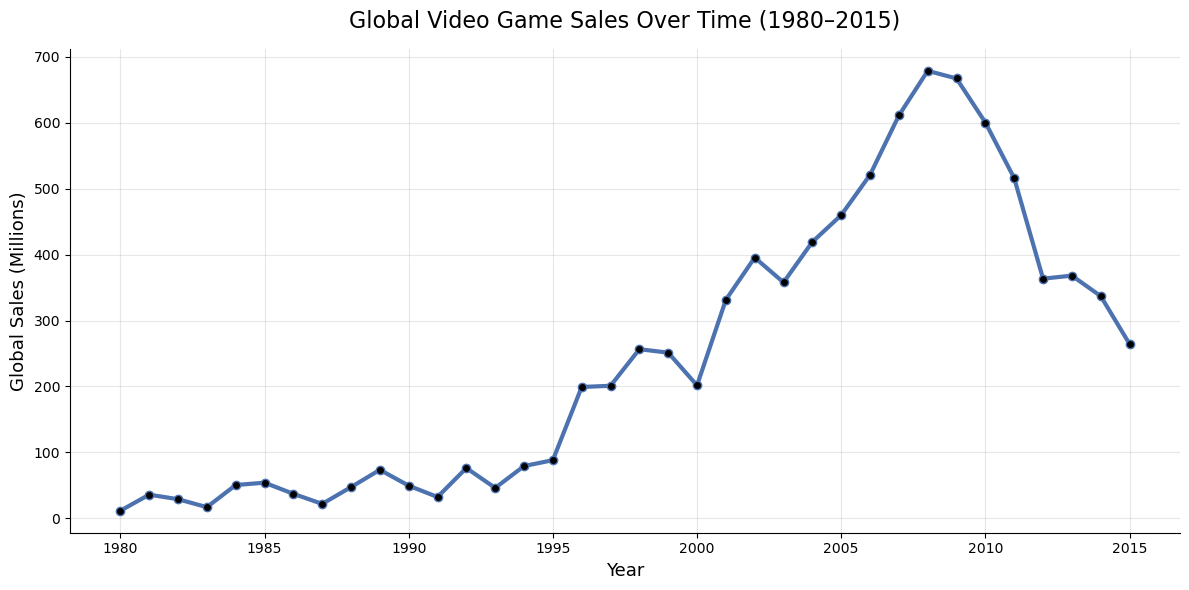

In [ ]:
# Step 3 - Create Visual Representation of Global Sales (filtered between 1980 - 2015)

import matplotlib.pyplot as plt

# 1. Aggregate global sales by year ---
df_years = df.dropna(subset=["Year"])
sales_per_year = (
    df_years.groupby("Year")["Global_Sales"]
            .sum()
            .sort_index()
)

# 2. Filter to reliable period (1980–2015) ---
sales_filtered = sales_per_year.loc[1980:2015]

# 3. Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    sales_filtered.index,
    sales_filtered.values,
    marker='o',
    markerfacecolor = "black",
    linewidth=3,
    color="#4C72B0"
)

# 4. Styling 
ax.set_title("Global Video Game Sales Over Time (1980–2015)", fontsize=16, pad=15)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Global Sales (Millions)", fontsize=13)

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha=0.3)

plt.tight_layout()

# 5. Save output
plt.savefig("outputs/q2_global_sales_over_time.png", dpi=300, bbox_inches="tight")

plt.show()

# Sanity Check

# - The filtered dataset should contain 36 years (1980–2015).  
# - The 2001–2008 era should show the highest sustained peak.  
# - The 1996–1998 jump should be clearly visible.  
# - The decline after 2010 should appear gradual, not catastrophic.  



In [7]:
# Step 2 - Decision 1 - Drop Missing Year Rows, or Investigate First?

# Verification before Trusting.

missing_year = df[df["Year"].isnull()]

# print(f"Missing year rows: {len(missing_year)}")

# print("\nTop publishers with missing years:")
# print(missing_year["Publisher"].value_counts().head(5))

# print("\nTop platforms with missing years:")
# print(missing_year["Platform"].value_counts().head(5))

# Aggregate Global Sales by Year.

# 1. Drop missing Year rows (after verifying)
df_years = df.dropna(subset=["Year"])

# 2. Aggregate global sales by year
sales_per_year = (
    df_years.groupby("Year")["Global_Sales"]
            .sum()
            .sort_index()   
)

# 3. Sanity check
# print(f"Year range: {sales_per_year.index.min()} to {sales_per_year.index.max()}")
# print(f"Years in dataset: {sales_per_year.shape[0]}")
# print(sales_per_year.head())
# print(sales_per_year.tail())
print(sales_per_year)



Year
1980.0     11.38
1981.0     35.77
1982.0     28.86
1983.0     16.79
1984.0     50.36
1985.0     53.94
1986.0     37.07
1987.0     21.74
1988.0     47.22
1989.0     73.45
1990.0     49.39
1991.0     32.23
1992.0     76.16
1993.0     45.98
1994.0     79.17
1995.0     88.11
1996.0    199.15
1997.0    200.98
1998.0    256.47
1999.0    251.27
2000.0    201.56
2001.0    331.47
2002.0    395.52
2003.0    357.85
2004.0    419.31
2005.0    459.94
2006.0    521.04
2007.0    611.13
2008.0    678.90
2009.0    667.30
2010.0    600.45
2011.0    515.99
2012.0    363.54
2013.0    368.11
2014.0    337.05
2015.0    264.44
2016.0     70.93
2017.0      0.05
2020.0      0.29
Name: Global_Sales, dtype: float64


In [2]:
# Step 1 - Load & Inspect Dataset.

import pandas as pd
from pathlib import Path

SCRIPT_DIR = Path().resolve()
df = pd.read_csv(SCRIPT_DIR / "data" / "vgsales.csv")
df.columns = df.columns.str.strip()

# Standard inspection
df.shape
df.columns.tolist()
df.dtypes
df.head()
df["Publisher"].nunique()
df["Publisher"].value_counts().head(10)
df["Year"].min(), df["Year"].max()
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64